In [1]:
# Для анализа и разметки данных
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from PIL import Image, ImageOps
from IPython.display import display, clear_output
import csv
import random
from sklearn.preprocessing import StandardScaler

# Для обучения RankNet
import wandb
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from scipy.stats import kendalltau
import copy

In [ ]:
wandb.login() # вставить API ключ от аккаунта W&B

In [42]:
features_df = pd.read_csv('/kaggle/input/datasets/neuromant/building-features-300-40d-nan-checked/building_features_300-40d-nan-checked.csv')
features_df['building_name'] = features_df['building_name'].astype(str)
features_df.set_index('building_name', inplace=True)

# Глобальный scaler убран — теперь каждая сессия обучает свой scaler
# только на тренировочных зданиях (Fix #3). Скалеры хранятся в trained_scalers.

class PairwiseDataset(Dataset):
    """
    Принимает scaler, обученный ТОЛЬКО на зданиях из train-пар.
    Нормализация происходит внутри датасета — это исключает
    случайную передачу сырых данных в модель.
    """
    def __init__(self, pairs_df, features_df, feature_cols, scaler):
        self.features_a, self.features_b, self.labels = [], [], []

        for _, row in pairs_df.iterrows():
            img_a, img_b, winner = str(row['image_a']), str(row['image_b']), str(row['winner'])
            if winner not in ['0', '1', '2']: continue
            if img_a not in features_df.index or img_b not in features_df.index: continue

            vec_a = features_df.loc[img_a, feature_cols].values.astype(np.float32)
            vec_b = features_df.loc[img_b, feature_cols].values.astype(np.float32)

            # Нормализуем через scaler, обученный на train-зданиях
            vec_a = scaler.transform(vec_a.reshape(1, -1))[0].astype(np.float32)
            vec_b = scaler.transform(vec_b.reshape(1, -1))[0].astype(np.float32)

            label = 1.0 if winner == '0' else (0.0 if winner == '1' else 0.5)
            self.features_a.append(vec_a)
            self.features_b.append(vec_b)
            self.labels.append(label)

        self.features_a = np.array(self.features_a, dtype=np.float32)
        self.features_b = np.array(self.features_b, dtype=np.float32)
        self.labels     = np.array(self.labels, dtype=np.float32)

    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        return torch.tensor(self.features_a[idx]), torch.tensor(self.features_b[idx]), torch.tensor(self.labels[idx])


## Другой вариант RankNet

In [43]:
class RankNetHead(nn.Module):
    def __init__(self, input_dim=8, hidden_dim=32, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),   # стабилизирует обучение на малых данных
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1)    # скалярный score
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x_a, x_b):
        """Возвращает разность score_a - score_b (logit для BCEWithLogitsLoss)"""
        return self.net(x_a).squeeze(-1) - self.net(x_b).squeeze(-1)

    def predict_score(self, x):
        """Абсолютный score для ранжирования на инференсе"""
        with torch.no_grad():
            return torch.sigmoid(self.net(x))


SESSIONS = ['coating_deterioration', 'cracks', 'masonry_degradation', 'moisture_bio_damage', 'vandalism']
trained_models  = {}
trained_scalers = {}  # Fix #3: per-session scaler, обученный только на train-зданиях

for session in SESSIONS:
    pairs_file = f'/kaggle/input/datasets/neuromant/ranking-dataset-300-imgs/ranking_dataset- 300-imgs/ranking_pairs_{session}.csv'
    if not os.path.exists(pairs_file): continue

    pairs_df = pd.read_csv(pairs_file)
    if len(pairs_df) < 20: continue

    train_df, val_df = train_test_split(pairs_df, test_size=0.2, random_state=42)
    # feature_cols = [f"{session}_mean", f"{session}_max", f"{session}_prevalence"]
    feature_cols = [
    f"{session}_mean",         f"{session}_max",
    f"{session}_prevalence",   f"{session}_std",
    f"{session}_q75",          f"{session}_skewness",
    f"{session}_concentration",f"{session}_severity_coverage",
]

    # Fix #3: fit scaler ТОЛЬКО на зданиях из тренировочных пар
    train_building_names = set(train_df['image_a'].tolist() + train_df['image_b'].tolist())
    train_mask   = features_df.index.isin(train_building_names)
    session_scaler = StandardScaler()
    session_scaler.fit(features_df.loc[train_mask, feature_cols].values)
    trained_scalers[session] = session_scaler

    train_dataset = PairwiseDataset(train_df, features_df, feature_cols, session_scaler)
    val_dataset   = PairwiseDataset(val_df,   features_df, feature_cols, session_scaler)

    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
    val_loader   = DataLoader(val_dataset,   batch_size=len(val_dataset), shuffle=False)

    model     = RankNetHead(input_dim=8, hidden_dim=32, dropout=0.3)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=10)

    best_tau        = -1.0
    best_state      = None
    patience_counter = 0
    PATIENCE        = 20

    wandb.init(project="master-thesis-ranknet", name=f"run_{session}", reinit=True)
    print(f"\n--- Обучение: {session.upper()} (Train: {len(train_dataset)} | Val: {len(val_dataset)}) ---")

    EPOCHS = 100
    for epoch in range(EPOCHS):
        model.train()
        total_loss = 0.0

        for vec_a, vec_b, labels in train_loader:
            optimizer.zero_grad()
            diff_scores = model(vec_a, vec_b)
            loss = criterion(diff_scores, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        epoch_loss = total_loss / len(train_loader)

        model.eval()
        with torch.no_grad():
            for val_a, val_b, val_labels in val_loader:
                val_diff_scores = model(val_a, val_b)
                val_loss = criterion(val_diff_scores, val_labels).item()
                tau_b, _ = kendalltau(val_labels.numpy(), val_diff_scores.numpy())
                if np.isnan(tau_b): tau_b = 0.0

        if tau_b > best_tau:
            best_tau = tau_b
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f"Early stopping на эпохе {epoch+1}")
                model.load_state_dict(best_state)
                break

        scheduler.step(tau_b)
        wandb.log({"epoch": epoch, "train_loss": epoch_loss, "val_loss": val_loss, "val_tau_b": tau_b})

        if (epoch+1) % 20 == 0:
            print(f"Epoch {epoch+1:03d}/{EPOCHS} | Train Loss: {epoch_loss:.4f} | Val Loss: {val_loss:.4f} | Val Tau-b: {tau_b:.3f}")

    trained_models[session] = model
    wandb.finish()

print("\nОбучение завершено!")



--- Обучение: COATING_DETERIORATION (Train: 164 | Val: 41) ---
Epoch 020/100 | Train Loss: 0.4984 | Val Loss: 0.5371 | Val Tau-b: 0.473
Early stopping на эпохе 29


epoch,▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇██
train_loss,█▆▄▄▂▂▂▂▂▂▂▂▂▁▂▂▂▂▁▂▁▂▁▁▂▂▁▁
val_loss,█▃▂▁▁▁▁▁▁▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂
val_tau_b,▁▆██████████████████████████
epoch,27
train_loss,0.464
val_loss,0.53673
val_tau_b,0.47281



--- Обучение: CRACKS (Train: 81 | Val: 21) ---
Epoch 020/100 | Train Loss: 0.7209 | Val Loss: 0.6344 | Val Tau-b: 0.285
Epoch 040/100 | Train Loss: 0.6355 | Val Loss: 0.6300 | Val Tau-b: 0.335
Early stopping на эпохе 60


epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇███
train_loss,▆▆▇▅▃▅▆▆▄▃▄▃▅▄▄▄▃█▃▅▃▂▃▅▃▃▃▇▃▂▂▃▁▂▂▃▁▁▁▂
val_loss,█▅▄▃▃▂▂▂▂▂▁▁▁▁▁▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_tau_b,▁▂▃▄▄▅▅▅▆▆▇▇▇▇▇▇▇▇▇▆▇▇▇█████████████████
epoch,58
train_loss,0.57677
val_loss,0.62952
val_tau_b,0.30997



--- Обучение: MASONRY_DEGRADATION (Train: 157 | Val: 40) ---
Epoch 020/100 | Train Loss: 0.5020 | Val Loss: 0.6228 | Val Tau-b: 0.353
Early stopping на эпохе 24


...


--- Обучение: MOISTURE_BIO_DAMAGE (Train: 169 | Val: 43) ---
Epoch 020/100 | Train Loss: 0.4759 | Val Loss: 0.4960 | Val Tau-b: 0.478
Epoch 040/100 | Train Loss: 0.3674 | Val Loss: 0.4857 | Val Tau-b: 0.484
Early stopping на эпохе 56


epoch,▁▁▂▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇██
train_loss,█▅▄▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▂▂▁▂▂▂▂▁▂▂▁▁▁▂▂▁▂▂▂▁▁▁
val_loss,█▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_tau_b,▁▆▇█████████████████████████████████████
epoch,54
train_loss,0.38971
val_loss,0.48248
val_tau_b,0.4872



--- Обучение: VANDALISM (Train: 109 | Val: 28) ---
Epoch 020/100 | Train Loss: 0.5067 | Val Loss: 0.5483 | Val Tau-b: 0.412
Epoch 040/100 | Train Loss: 0.4670 | Val Loss: 0.5108 | Val Tau-b: 0.445
Epoch 060/100 | Train Loss: 0.4246 | Val Loss: 0.4731 | Val Tau-b: 0.485
Epoch 080/100 | Train Loss: 0.4169 | Val Loss: 0.4532 | Val Tau-b: 0.512
Epoch 100/100 | Train Loss: 0.4027 | Val Loss: 0.4401 | Val Tau-b: 0.539


epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇████
train_loss,█▅▄▃▃▃▃▃▃▂▂▃▂▂▂▂▁▂▂▂▂▂▂▂▂▁▂▂▁▁▁▁▂▁▁▁▂▁▁▁
val_loss,█▇▇▆▅▅▄▄▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁
val_tau_b,▁▂▅▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇██████████████
epoch,99
train_loss,0.40266
val_loss,0.44013
val_tau_b,0.53857



Обучение завершено!


In [17]:
# FEATURE_COLS = {
#     'coating_deterioration': ['mean', 'max', 'prevalence', 'std'],
#     'cracks':                ['mean', 'max', 'std', 'concentration'],
#     'masonry_degradation':   ['mean', 'max', 'prevalence', 'q75'],
#     'moisture_bio_damage':   ['mean', 'max', 'prevalence', 'std'],
#     'vandalism':             ['mean', 'max', 'prevalence'],
# }

In [40]:
import pandas as pd
import numpy as np
import os
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from scipy.stats import kendalltau

# ── Настройки ─────────────────────────────────────────────────────────────────
features_df = pd.read_csv('/kaggle/input/datasets/neuromant/building-features-300-40d-nan-checked/building_features_300-40d-nan-checked.csv')
features_df['building_name'] = features_df['building_name'].astype(str)
features_df.set_index('building_name', inplace=True)

SESSIONS = ['coating_deterioration', 'cracks', 'masonry_degradation',
            'moisture_bio_damage', 'vandalism']

# FEATURE_COLS = {session: ['mean', 'max', 'prevalence', 'std', 'q75',
#                            'skewness', 'concentration', 'severity_coverage']
#                 for session in SESSIONS}

FEATURE_COLS = {session: ['mean', 'max', 'prevalence', 'std', 'q75'] for session in SESSIONS}

N_FOLDS = 5

# ── Вспомогательная функция ───────────────────────────────────────────────────
def extract_pairs(df, feature_cols, scaler):
    """Строит матрицу разностей X и метки y из датафрейма пар."""
    X, y = [], []
    for _, row in df.iterrows():
        img_a, img_b, winner = str(row['image_a']), str(row['image_b']), str(row['winner'])
        if winner not in ['0', '1']:
            continue  # ничьи не подходят для LR
        if img_a not in features_df.index or img_b not in features_df.index:
            continue
        vec_a = scaler.transform(features_df.loc[img_a, feature_cols].values.reshape(1,-1))[0]
        vec_b = scaler.transform(features_df.loc[img_b, feature_cols].values.reshape(1,-1))[0]
        X.append(vec_a - vec_b)
        y.append(1 if winner == '0' else 0)
    return np.array(X, dtype=np.float32), np.array(y)

# ── Обучение + кросс-валидация ────────────────────────────────────────────────
print('=== Логистическая Регрессия: 5-Fold Cross-Validation ===\n')

lr_models_final  = {}  # финальные модели для инференса
lr_scalers_final = {}

for session in SESSIONS:
    pairs_file = f'/kaggle/input/datasets/neuromant/ranking-dataset-300-imgs/ranking_dataset- 300-imgs/ranking_pairs_{session}.csv'
    if not os.path.exists(pairs_file):
        print(f'[{session}] файл не найден\n')
        continue

    # Загружаем и сразу фильтруем ничьи
    pairs_df = (pd.read_csv(pairs_file)
                  .assign(winner=lambda d: d['winner'].astype(str))
                  .query("winner in ['0', '1']")
                  .reset_index(drop=True))

    if len(pairs_df) < N_FOLDS * 4:
        print(f'[{session}] слишком мало пар ({len(pairs_df)}), пропуск\n')
        continue

    feature_cols = [f"{session}_{f}" for f in FEATURE_COLS[session]]

    # ── Кросс-валидация ───────────────────────────────────────────────────────
    kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
    fold_taus, fold_accs = [], []

    for train_idx, val_idx in kf.split(pairs_df):
        train_fold = pairs_df.iloc[train_idx]
        val_fold   = pairs_df.iloc[val_idx]

        # Scaler обучается только на train-зданиях текущего фолда
        train_buildings = set(train_fold['image_a'].tolist() + train_fold['image_b'].tolist())
        train_mask = features_df.index.isin(train_buildings)
        fold_scaler = StandardScaler()
        fold_scaler.fit(features_df.loc[train_mask, feature_cols].values)

        X_train, y_train = extract_pairs(train_fold, feature_cols, fold_scaler)
        X_val,   y_val   = extract_pairs(val_fold,   feature_cols, fold_scaler)

        if len(X_train) == 0 or len(X_val) == 0 or len(np.unique(y_train)) < 2:
            continue

        lr = LogisticRegression(C=0.1, max_iter=1000, random_state=42)
        lr.fit(X_train, y_train)

        val_proba = lr.predict_proba(X_val)[:, 1]
        acc = accuracy_score(y_val, (val_proba > 0.5).astype(int))
        tau, _ = kendalltau(y_val, val_proba)
        fold_taus.append(0.0 if np.isnan(tau) else tau)
        fold_accs.append(acc)

    # ── Финальная модель на всех парах ────────────────────────────────────────
    # Кросс-валидация оценивает качество, но не даёт одну модель для инференса.
    # Финальная модель обучается на ВСЕХ парах с скейлером на ВСЕХ зданиях.
    all_buildings = set(pairs_df['image_a'].tolist() + pairs_df['image_b'].tolist())
    final_scaler = StandardScaler()
    final_scaler.fit(features_df.loc[features_df.index.isin(all_buildings), feature_cols].values)
    lr_scalers_final[session] = final_scaler

    X_all, y_all = extract_pairs(pairs_df, feature_cols, final_scaler)
    final_lr = LogisticRegression(C=0.1, max_iter=1000, random_state=42)
    final_lr.fit(X_all, y_all)
    lr_models_final[session] = final_lr

    # ── Результаты ────────────────────────────────────────────────────────────
    mean_tau = np.mean(fold_taus)
    std_tau  = np.std(fold_taus)
    per_fold = '  '.join([f'{t:.2f}' for t in fold_taus])

    print(f'[{session.upper():30s}]')
    print(f'   CV Tau:   {mean_tau:.3f} ± {std_tau:.3f}   по фолдам: [{per_fold}]')
    print(f'   Accuracy: {np.mean(fold_accs):.3f}')
    print(f'   Веса финальной модели: {final_lr.coef_[0].round(3)}')
    print(f'   Признаки: {FEATURE_COLS[session]}\n')

print(f'Готово. Обучено {len(lr_models_final)}/{len(SESSIONS)} финальных моделей.')


=== Логистическая Регрессия: 5-Fold Cross-Validation ===

[COATING_DETERIORATION         ]
   CV Tau:   0.502 ± 0.062   по фолдам: [0.48  0.61  0.42  0.49  0.52]
   Accuracy: 0.760
   Веса финальной модели: [0.177 0.221 0.405 0.402 0.207]
   Признаки: ['mean', 'max', 'prevalence', 'std', 'q75']

[CRACKS                        ]
   CV Tau:   0.315 ± 0.057   по фолдам: [0.31  0.33  0.21  0.35  0.37]
   Accuracy: 0.688
   Веса финальной модели: [ 0.224  0.303 -0.103  0.324  0.102]
   Признаки: ['mean', 'max', 'prevalence', 'std', 'q75']

[MASONRY_DEGRADATION           ]
   CV Tau:   0.492 ± 0.068   по фолдам: [0.52  0.61  0.42  0.44  0.48]
   Accuracy: 0.742
   Веса финальной модели: [-0.004  0.094  0.484  0.429  0.01 ]
   Признаки: ['mean', 'max', 'prevalence', 'std', 'q75']

[MOISTURE_BIO_DAMAGE           ]
   CV Tau:   0.532 ± 0.025   по фолдам: [0.51  0.55  0.50  0.56  0.54]
   Accuracy: 0.811
   Веса финальной модели: [ 0.141  0.336  0.501  0.451 -0.069]
   Признаки: ['mean', 'max', 

In [ ]:
# ── Инференс: LR → Global Damage Index ───────────────────────────────────────
results = []

for b_name, row in features_df.iterrows():
    b_dict = {'building_name': b_name}

    for session in SESSIONS:
        if session not in lr_models_final:
            continue

        feature_cols = [f"{session}_{f}" for f in FEATURE_COLS[session]]
        model  = lr_models_final[session]
        scaler = lr_scalers_final[session]

        vec        = row[feature_cols].values.astype(np.float32)
        vec_scaled = scaler.transform(vec.reshape(1, -1))[0]

        # Score = w^T · x  (без intercept — он учит асимметрию пар, не абсолютный уровень)
        score = float(vec_scaled @ model.coef_[0])
        b_dict[f"{session}_score"] = score

    results.append(b_dict)

final_scores_df = pd.DataFrame(results)
final_scores_df.set_index('building_name', inplace=True)
score_cols = [f"{s}_score" for s in SESSIONS if s in lr_models_final]

# ── Калибровка: якорь [0,...,0] → 0.0,  P99 → 1.0 ────────────────────────────
for col in score_cols:
    session      = col.replace('_score', '')
    model        = lr_models_final[session]
    scaler       = lr_scalers_final[session]
    feature_cols = [f"{session}_{f}" for f in FEATURE_COLS[session]]

    zero_scaled  = scaler.transform(np.zeros((1, len(feature_cols)), dtype=np.float32))
    anchor_score = float(zero_scaled @ model.coef_[0])

    shifted = final_scores_df[col] - anchor_score
    p99     = np.percentile(shifted, 99)

    if p99 > 0:
        final_scores_df[col] = np.clip(shifted / p99, 0.0, 1.0)
    else:
        final_scores_df[col] = 0.0

# ── Global Damage Index ───────────────────────────────────────────────────────

# Вариант усредненного GDI
# final_scores_df['Global_Damage_Index'] = final_scores_df[score_cols].mean(axis=1)
# final_scores_df.sort_values('Global_Damage_Index', ascending=False, inplace=True)

# Вариант взвешенного GDI
DAMAGE_WEIGHTS = {
    'vandalism':             0.5,
    'moisture_bio_damage':   0.5,
    'coating_deterioration': 1.0,
    'cracks':                1.0,
    'masonry_degradation':   2.0,
}

weights = np.array([DAMAGE_WEIGHTS[s] for s in SESSIONS if s in lr_models_final])
weights = weights / weights.sum()  # нормируем, чтобы GDI оставался в [0, 1]

final_scores_df['Global_Damage_Index'] = (
    final_scores_df[score_cols].values @ weights
)




# ── Вывод ─────────────────────────────────────────────────────────────────────
print("Топ-10 самых повреждённых зданий:")
display(final_scores_df.head(10))

print("\nСтатистика по индексам:")
display(final_scores_df[score_cols + ['Global_Damage_Index']].describe().round(3))

final_scores_df.to_csv('/kaggle/working/facade_damage_scores_lr.csv')
print("\nСохранено: facade_damage_scores_lr.csv")


Топ-10 самых повреждённых зданий:


/tmp/ipykernel_55/3570031169.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  anchor_score = float(zero_scaled @ model.coef_[0])
/tmp/ipykernel_55/3570031169.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  anchor_score = float(zero_scaled @ model.coef_[0])
/tmp/ipykernel_55/3570031169.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  anchor_score = float(zero_scaled @ model.coef_[0])
/tmp/ipykernel_55/3570031169.py:36: DeprecationWarning: Conversion of 

,coating_deterioration_score,cracks_score,masonry_degradation_score,moisture_bio_damage_score,vandalism_score,Global_Damage_Index
building_name,,,,,,
9,0.493303,0.089758,0.853270,0.227240,1.000000,0.532714
DSC02259,0.894509,0.048565,1.000000,0.127276,0.516943,0.517459
IMG_20260410_141005863_HDR,1.000000,0.544883,0.173270,0.510416,0.091741,0.464062
IMG_20260317_113335801_HDR,0.866738,0.015868,0.894502,0.133676,0.113021,0.404761
14,0.585166,0.074118,0.999990,0.333400,0.000000,0.398535
DSC02210,0.370098,0.513216,0.622523,0.432354,0.037675,0.395173
IMG_20260410_141717983_HDR,0.948285,0.013573,0.536783,0.405310,0.010356,0.382862
IMG_20260317_130539386_HDR,0.990550,0.058122,0.830364,0.008501,0.017381,0.380984
IMG_20260410_135002890_HDR,0.575691,0.103200,0.006640,1.000000,0.153385,0.367783



Статистика по индексам:


,coating_deterioration_score,cracks_score,masonry_degradation_score,moisture_bio_damage_score,vandalism_score,Global_Damage_Index
count,300.000,300.000,300.000,300.000,300.000,300.000
mean,0.265,0.090,0.098,0.211,0.052,0.143
std,0.261,0.146,0.180,0.234,0.128,0.102
min,0.001,0.000,0.000,0.000,0.000,0.005
25%,0.064,0.017,0.010,0.024,0.003,0.060
50%,0.173,0.042,0.031,0.132,0.016,0.118
75%,0.410,0.099,0.089,0.327,0.049,0.205
max,1.000,1.000,1.000,1.000,1.000,0.533



Сохранено: facade_damage_scores_lr.csv


In [ ]:
# Можно сохранить финал:
final_scores_df.to_csv('facade_damage_scores_ranked.csv', index=False)

,coating_deterioration_score,cracks_score,masonry_degradation_score,moisture_bio_damage_score,vandalism_score
count,300.000000,300.000000,300.000000,300.000000,300.000000
mean,0.306157,0.167072,0.080372,0.213118,0.041340
std,0.348896,0.283024,0.247175,0.317704,0.159163
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.004161,0.000000
50%,0.084181,0.036675,0.000000,0.038814,0.000000
75%,0.623644,0.135179,0.000000,0.271297,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000


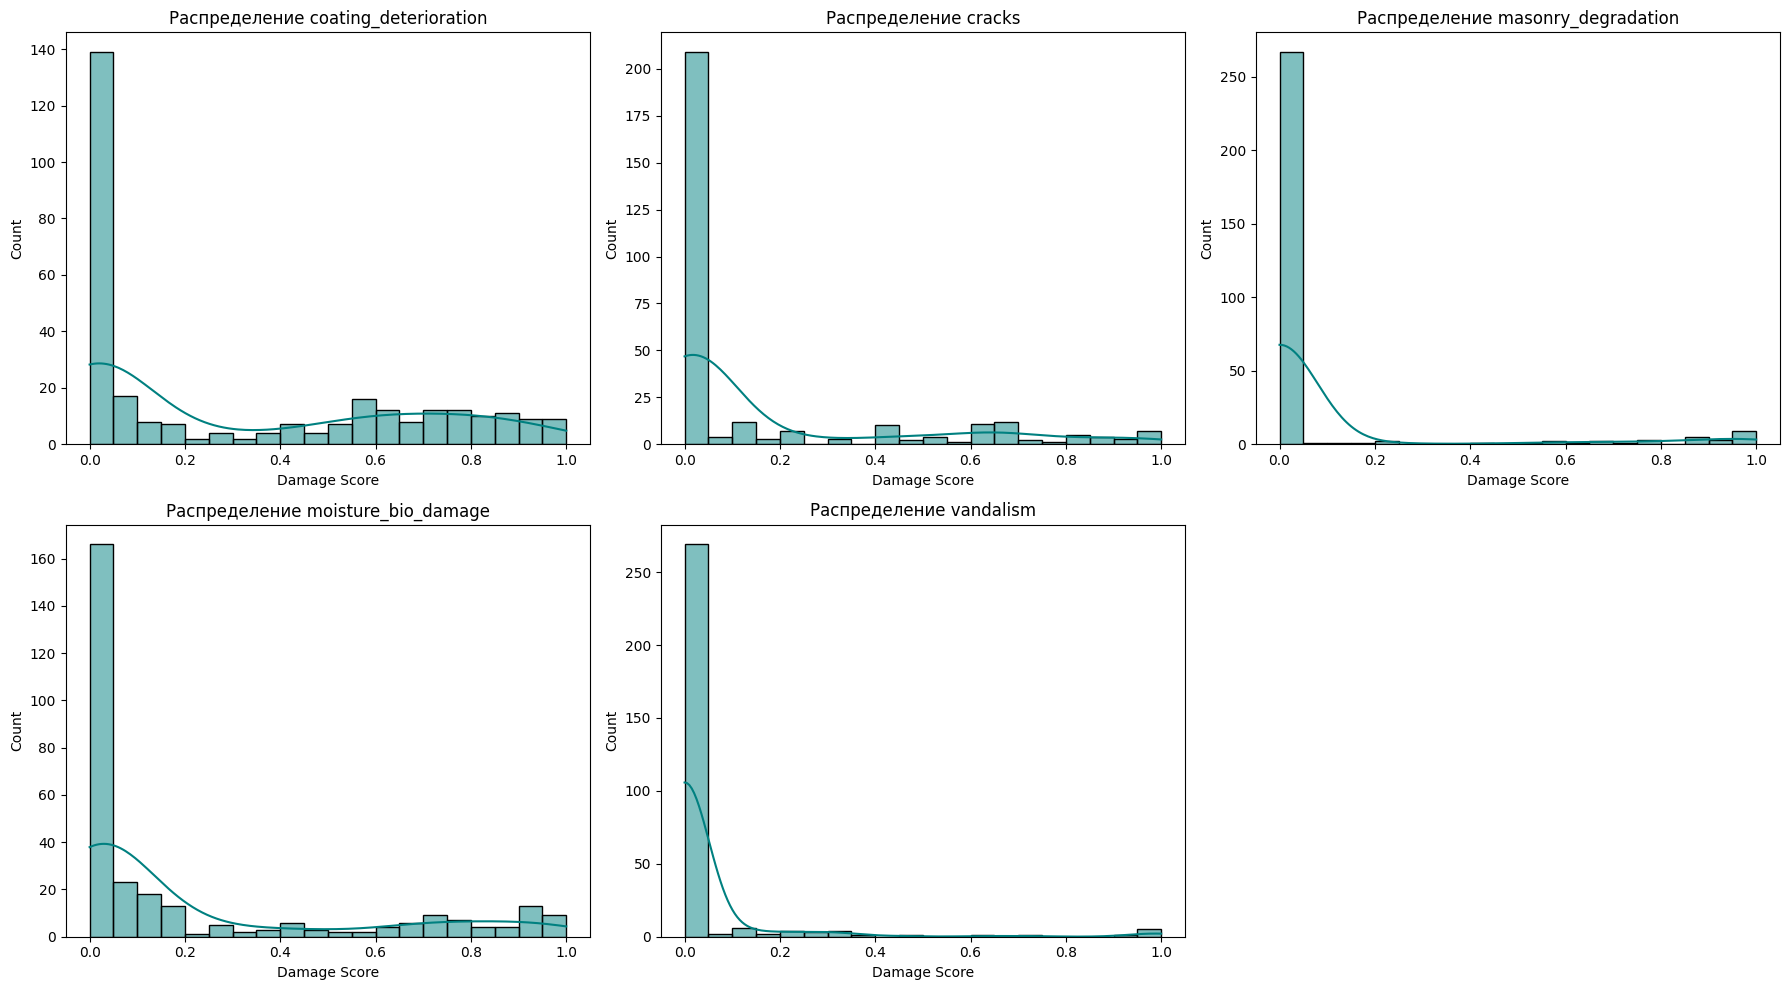

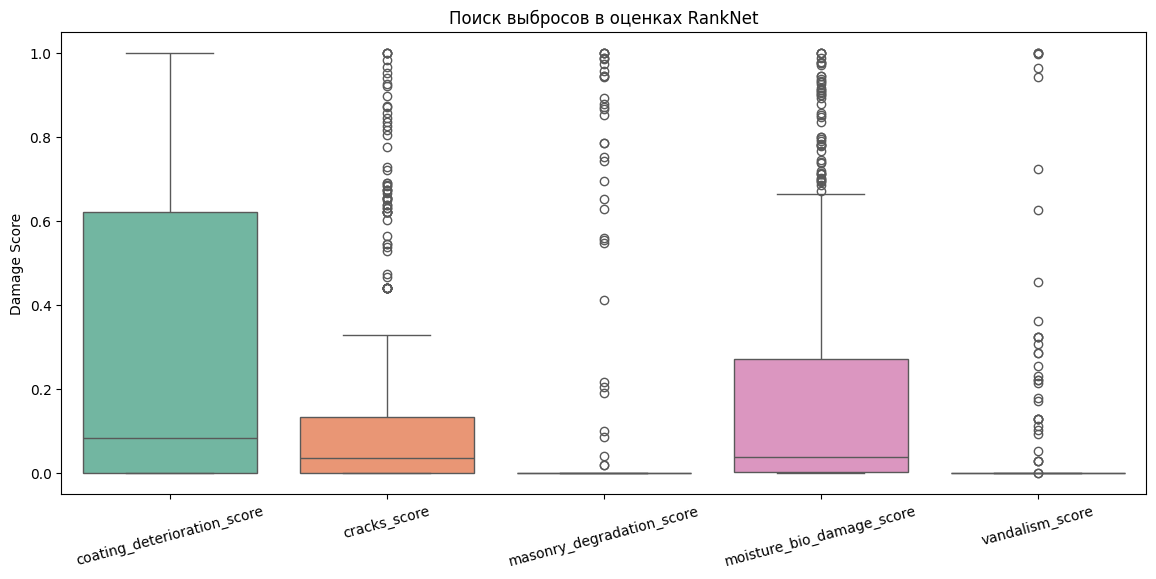

\Топ самых поврежденных зданий


KeyError: "['building_name'] not in index"

In [7]:
# Вывод статистик
display(final_scores_df[score_cols].describe())

# Распределения
plt.figure(figsize=(18, 10))
for i, col in enumerate(score_cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(final_scores_df[col], bins=20, kde=True, color='teal')
    plt.title(f'Распределение {col.replace("_score", "")}')
    plt.xlabel("Damage Score")
plt.tight_layout()
plt.show()

# Выбросы
# Попробуем понять, является ли супер-разрушенный фасад аномалией 
# или равномерно вписывается в общий тренд
plt.figure(figsize=(14, 6))
sns.boxplot(data=final_scores_df[score_cols], palette="Set2")
plt.xticks(rotation=15)
plt.title("Поиск выбросов в оценках RankNet")
plt.ylabel("Damage Score")
plt.show()

# Визуальное сопоставление (sanity check)
print("\Топ самых поврежденных зданий")
for col in score_cols:
    top_buildings = final_scores_df.nlargest(5, col)[['building_name', col]]
    clean_name = col.replace('_score', '').upper()
    print(f"\nТоп-5 худших по {clean_name}:")
    for _, row in top_buildings.iterrows():
        print(f" - Фасад: {row['building_name']}.jpg (Оценка RankNet: {row[col]:.3f})")
